In [19]:
import json
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.readwrite import json_graph
from pathlib import Path
import os
import sys
import subprocess
repo_root = Path(subprocess.check_output(
    ['git', 'rev-parse', '--show-toplevel'], text=True
).strip())
sys.path.insert(0, str(repo_root))

from pipeline.metrics import moran, gini, frey, dissimilarity, assortativity, property_sum, half_edge
from pipeline.metrics import make_adj_weights

In [20]:
graph_dir = repo_root / "data/processed/dual_graphs"
cluster_csv = repo_root / "experiments/h4_t3_observed_diffusion/data/auto_cluster_tracts.csv"
geography = "cbsa"

CITIES = {
    "chicago": 16980,
    "philadelphia": 37980,
}
##USE FOR 
CITIES = {
    "chicago": 16980,
    "philadelphia": 37980,
}

YEARS = [1980, 1990, 2000, 2010, 2020]

# Load city-wide graphs: graphs[(city, year)] -> nx.Graph
graphs = {}
for city, area_code in CITIES.items():
    for year in YEARS:
        path = graph_dir / str(year) / f"tracts_in_{geography}_{area_code}_{year}_march_2020_vintage_connected.json"
        with open(path) as f:
            graphs[(city, year)] = nx.adjacency_graph(json.load(f))

# Build cluster membership lookup from the CSV
# cluster_nodes[(city, year, cluster_title)] -> set of node ids in the city-wide graph
df = pd.read_csv(cluster_csv)

cluster_nodes = {}
for city, area_code in CITIES.items():
    city_df = df[df["cbsa"] == area_code]
    for year in YEARS:
        G = graphs[(city, year)]
        gisjoin_to_nodeid = {data["GISJOIN"]: node for node, data in G.nodes(data=True)}
        year_df = city_df[city_df["year"] == year]
        for cluster_title, group in year_df.groupby("cluster_title"):
            node_ids = set()
            for gisjoin in group["gisjoin"]:
                if gisjoin in gisjoin_to_nodeid:
                    node_ids.add(gisjoin_to_nodeid[gisjoin])
            cluster_nodes[(city, year, cluster_title)] = node_ids

# Example: subgraph of Chicago South Side 1980 within the city-wide graph
cluster_nodes


{('chicago', 1980, 'Chicago, Austin'): {132,
  139,
  140,
  178,
  180,
  182,
  183,
  185,
  186,
  187,
  188,
  189,
  205,
  206,
  285,
  287,
  300,
  303,
  390,
  477,
  483,
  484,
  485,
  486,
  487,
  488,
  489,
  495,
  532,
  552,
  553,
  554,
  556,
  557,
  558,
  559,
  560,
  562,
  563,
  566,
  567,
  569,
  570,
  571,
  572,
  573,
  652,
  656,
  658,
  685,
  700,
  711,
  754,
  757,
  772,
  773,
  795,
  796,
  797,
  836,
  837,
  838,
  844,
  872,
  873,
  874,
  907,
  1002,
  1003,
  1005,
  1006,
  1008,
  1009,
  1033,
  1034,
  1134,
  1136,
  1148,
  1149,
  1150,
  1151,
  1153,
  1154,
  1182,
  1183,
  1184,
  1185,
  1188,
  1190,
  1233,
  1234,
  1236,
  1238,
  1239,
  1244,
  1245,
  1246,
  1254,
  1262,
  1285,
  1286,
  1304,
  1305,
  1306,
  1307,
  1309,
  1310,
  1318,
  1320,
  1322,
  1323,
  1324,
  1330,
  1331,
  1332,
  1336,
  1338,
  1339,
  1377,
  1378,
  1388,
  1665},
 ('chicago', 1980, 'Chicago, South Side'): {39,
  40

In [21]:
nodes = cluster_nodes[("chicago", 1980, "Chicago, South Side")]
graph = graphs[("chicago", 1980)]

top_sum = 0

shares = np.array([
    graph.nodes[node]["BLACK"] / graph.nodes[node]["TOTPOP"]
    for node in graph.nodes()
    ])

shares -= shares.mean()
node_to_i = {node: i for i, node in enumerate(graph.nodes())}

top_sum = 0
bottom_sum = 0
for i, node in enumerate(graph.nodes()):
    bottom_sum += shares[i] ** 2
    if node in nodes:
        for nbr in graph.neighbors(node):
            top_sum += shares[i] * shares[node_to_i[nbr]]
    
local_moran = len(graph) * (top_sum / bottom_sum)
local_moran

np.float64(3551.622044670844)

In [22]:
def local_moran(graph, cluster_nodes):
    shares = np.array([
        graph.nodes[node]["BLACK"] / graph.nodes[node]["TOTPOP"]
        for node in graph.nodes()
    ])
    shares -= shares.mean()
    node_to_i = {node: i for i, node in enumerate(graph.nodes())}

    top_sum = 0
    bottom_sum = 0
    for i, node in enumerate(graph.nodes()):
        bottom_sum += shares[i] ** 2
        if node in cluster_nodes:
            for nbr in graph.neighbors(node):
                top_sum += shares[i] * shares[node_to_i[nbr]]
    
    return len(graph)/len(graph.edges()) * (top_sum / bottom_sum)

In [23]:
years = [1980, 1990, 2000, 2010, 2020]


In [24]:
years = [1980, 1990, 2000, 2010, 2020]
for year in years:
    graph = graphs[("chicago", year)]
    nodes = cluster_nodes[("chicago", year, "Chicago, Austin")]
    print(f"Year {year}: Local Moran's I = {local_moran(graph, nodes)}")

Year 1980: Local Moran's I = 0.30331000298362065
Year 1990: Local Moran's I = 0.2992876068270798
Year 2000: Local Moran's I = 0.267876832992546
Year 2010: Local Moran's I = 0.21948266288925375
Year 2020: Local Moran's I = 0.19522253837197304


In [25]:
years = [1980, 1990, 2000, 2010, 2020]
for year in years:
    graph = graphs[("philadelphia", year)]
    nodes = cluster_nodes[("philadelphia", year, "Philadelphia, Germantown")]
    print(f"Year {year}: Local Moran's I = {local_moran(graph, nodes)}")

Year 1980: Local Moran's I = 0.5451480443699402
Year 1990: Local Moran's I = 0.5739835946451266
Year 2000: Local Moran's I = 0.5549502462825118
Year 2010: Local Moran's I = 0.5409364260401941
Year 2020: Local Moran's I = 0.5246076011326511


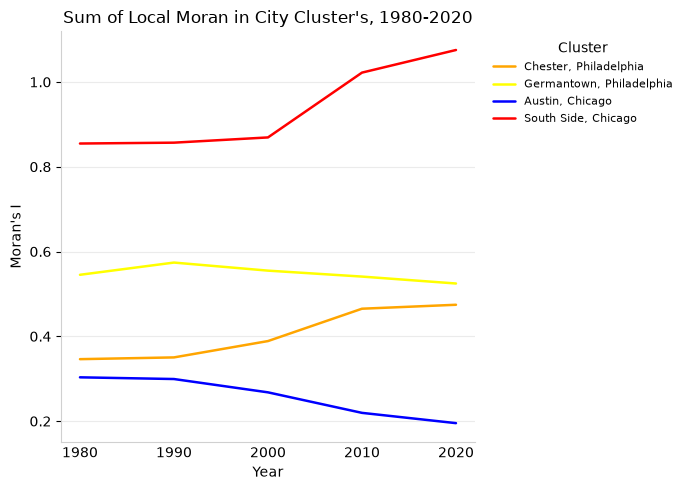

In [26]:
years = [1980, 1990, 2000, 2010, 2020]

fig, ax = plt.subplots(figsize=(7, 5))
chester = []
germantown = []
austin = []
southside = []

for year in years:
    graph = graphs[("philadelphia", year)]
    nodes = cluster_nodes[("philadelphia", year, "Philadelphia, Chester")]
    chester.append(local_moran(graph, nodes))

for year in years:
    graph = graphs[("philadelphia", year)]
    nodes = cluster_nodes[("philadelphia", year, "Philadelphia, Germantown")]
    germantown.append(local_moran(graph, nodes))

for year in years:
    graph = graphs[("chicago", year)]
    nodes = cluster_nodes[("chicago", year, "Chicago, South Side")]
    southside.append(local_moran(graph, nodes))

for year in years:
    graph = graphs[("chicago", year)]
    nodes = cluster_nodes[("chicago", year, "Chicago, Austin")]
    austin.append(local_moran(graph, nodes))

ax.plot(years, chester, color="orange", linewidth=1.8,
    solid_capstyle="round", label="Chester, Philadelphia")
ax.plot(years, germantown, color="yellow", linewidth=1.8,
    solid_capstyle="round", label="Germantown, Philadelphia")
ax.plot(years, austin, color="blue", linewidth=1.8,
    solid_capstyle="round", label="Austin, Chicago")
ax.plot(years, southside, color="red", linewidth=1.8,
    solid_capstyle="round", label="South Side, Chicago")
    
ax.set_xticks(years)
ax.set_xlabel("Year")
ax.set_ylabel("Moran's I")
ax.xaxis.set_tick_params(length=0)
ax.grid(axis="y", color="#ebebeb", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left",
        fontsize=8, frameon=False)
ax.set_title(f"Sum of Local Moran in City Cluster's, 1980-2020")
plt.tight_layout()
fig.savefig(f"../figures/Local Moran Sum in Cluster's in {geography}", dpi=150, bbox_inches="tight")
plt.show()